# Practica 2: Prendas de vestir

In [4]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Cargue el conjunto de datos Fashion MNIST

fmnist = keras.datasets.fashion_mnist

# Cargar la division de entrenamiento y prueba del conjunto de datos

(training_images, training_labels), (test_images, test_labels) = fmnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step 
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step


Label: 0
Image: [[  0   0   0   0   0   1   0   0   0   0  41 188 103  54  48  43  87 168 133  16   0   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0  49 136 219 216 228 236 255 255 255 255 217 215 254 231 160  45   0   0   0   0   0]
 [  0   0   0   0   0  14 176 222 224 212 203 198 196 200 215 204 202 201 201 201 209 218 224 164   0   0   0   0]
 [  0   0   0   0   0 188 219 200 198 202 198 199 199 201 196 198 198 200 200 200 200 201 200 225  41   0   0   0]
 [  0   0   0   0  51 219 199 203 203 212 238 248 250 245 249 246 247 252 248 235 207 203 203 222 140   0   0   0]
 [  0   0   0   0 116 226 206 204 207 204 101  75  47  73  48  50  45  51  63 113 222 202 206 220 224   0   0   0]
 [  0   0   0   0 200 222 209 203 215 200   0  70  98   0 103  59  68  71  49   0 219 206 214 210 250  38   0   0]
 [  0   0   0   0 247 218 212 210 215 214   0 254 243 139 255 174 251 255 205   0 215 217 214 208 220  95   0   0]
 [  0   0   0  45 226 214 214 215 224 205   0  42  35  60  16  1

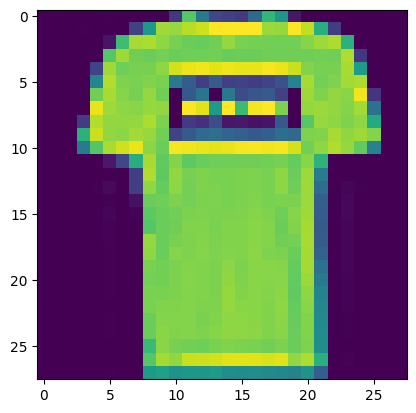

In [7]:
index = 1

# Imprimir la etiqueta de la imagen

np.set_printoptions(linewidth=200)
print(f'Label: {training_labels[index]}')
print(f'Image: {training_images[index]}')

# Visualizar la imagen
plt.imshow(training_images[index])

In [8]:
# Normalizar los valores de pixeles

training_images = training_images / 255.0
test_images = test_images / 255.0

In [9]:
# Construir el modelo de clasificacion

model = keras.models.Sequential([keras.layers.Flatten(input_shape=(28,28)),
                                 keras.layers.Dense(128, activation='relu'),
                                 keras.layers.Dense(10, activation='softmax')
])

/home/initmanfig/Documents/Course IA 2/._envIris/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-14 11:05:26.077317: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

In [16]:
# Entrenar el modelo
history = model.fit(training_images, training_labels, epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9131 - loss: 0.2290
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9168 - loss: 0.2204
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9185 - loss: 0.2186
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9216 - loss: 0.2088
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9252 - loss: 0.2023
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9261 - loss: 0.1981
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9266 - loss: 0.1916
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9306 - loss: 0.1879
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9321 - loss: 0.1803
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9344 - loss: 0.1762
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9350 - loss: 0.1741
Epoch 12/20
1875/1875

<Axes: >

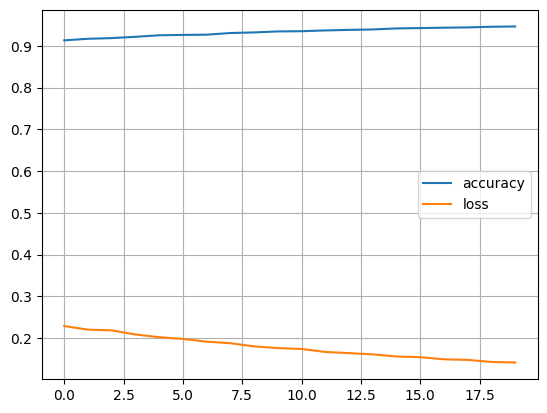

In [18]:
# Graficar el historial de entrenamiento
pd.DataFrame(history.history).plot(grid=True)

In [19]:
print(f'Label: {test_labels[index]}')
clasification = model.predict(test_images[index:index+1])
print(f'Clasificacion: {clasification.reshape(-1,1)}')

Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Clasificacion: [[4.2840849e-08]
 [7.1302749e-20]
 [9.9996638e-01]
 [1.7325434e-25]
 [3.3565793e-05]
 [4.6036189e-19]
 [2.1478630e-08]
 [6.4407768e-29]
 [2.8751117e-16]
 [2.5646817e-22]]


In [20]:
print(clasification.argmax())

2


In [21]:
# consultar el numero de entradas que tiene mi entrenamiento en cada iteracion

training_images.shape[1]

28

In [22]:
# guardando el modelo
ruta_guardar = '../modelos/fash_vest-94.keras'

model.save(ruta_guardar)